# PopOut — Decision Tree AI Pipeline

This notebook covers the full decision-tree pipeline for learning to play PopOut:

1. **Dataset generation** — parallel self-play with the MCTS-Solver records (board state, best move) pairs
2. **Data exploration** — class distribution, feature overview
3. **ID3 classifier** — train on all features, inspect feature importance
4. **Feature sweep** — find the minimum number of features needed to play well
5. **Win-rate evaluation** — measure how often the tree beats FlatNumbaSolverMCTS

In [14]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.decision_tree.id3.learner import ID3Classifier
from src.decision_tree.dataset_generator import generate_dataset_parallel
from src.engine.standard.bitboard import PopOutBoard
from src.engine.standard.rules import evaluate_after_move

plt.style.use('ggplot')
print(f'CPU cores available: {os.cpu_count()}')

CPU cores available: 16


## 1. Dataset Generation

Each sample is generated by:
1. Randomising a board position (0–20 random moves from the opening)
2. Querying **FlatNumbaSolverMCTS** (full Numba JIT loop, 30–60k iter/s) for the best move

`generate_dataset_parallel` distributes the work across all CPU cores using
`ProcessPoolExecutor`.  Each worker creates its own `FlatNumbaSolverMCTS` instance,
bypassing the GIL so all cores run simultaneously.  The solver exits early once a
position is **proven** (forced win/loss/draw), so the effective iteration count is
often well below the 100 000 maximum — complex mid-game positions use more,
simple end-game positions use far fewer.

In [15]:
N_SAMPLES  = 1000      # total (board, move) pairs to generate
ITERATIONS = 100_000   # MCTS iterations per position (FlatNumbaSolverMCTS exits early when proven)
DATA_PATH  = Path('../data/generated/popout_dt_dataset.csv')
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

print(f'Generating {N_SAMPLES} samples with up to {ITERATIONS:,} MCTS iterations each ...')
print(f'Workers: {os.cpu_count()} cores  |  Engine: FlatNumbaSolverMCTS')
t0 = time.perf_counter()

df = generate_dataset_parallel(
    n_samples=N_SAMPLES,
    iterations=ITERATIONS,
    seed=42,
)

elapsed = time.perf_counter() - t0
df.to_csv(DATA_PATH, index=False)

print(f'Done in {elapsed:.1f} s  ({elapsed/len(df)*1000:.1f} ms/sample)')
print(f'Dataset: {df.shape[0]} rows × {df.shape[1]} columns  →  {DATA_PATH}')

Generating 1000 samples with up to 100,000 MCTS iterations each ...
Workers: 16 cores  |  Engine: FlatNumbaSolverMCTS
Done in 40.6 s  (40.6 ms/sample)
Dataset: 1000 rows × 44 columns  →  ../data/generated/popout_dt_dataset.csv


## 2. Data Exploration

In [16]:
TARGET       = 'best_move'
FEATURE_COLS = [c for c in df.columns if c != TARGET]

print(f'Features : {len(FEATURE_COLS)}  ({FEATURE_COLS[:5]} ... {FEATURE_COLS[-1]})')
print(f'Classes  : {df[TARGET].nunique()} unique moves')
print()
df.head(3)

Features : 43  (['cell_0_0', 'cell_0_1', 'cell_0_2', 'cell_0_3', 'cell_0_4'] ... current_player)
Classes  : 13 unique moves



,cell_0_0,cell_0_1,cell_0_2,cell_0_3,cell_0_4,cell_0_5,cell_0_6,cell_1_0,cell_1_1,cell_1_2,...,cell_4_6,cell_5_0,cell_5_1,cell_5_2,cell_5_3,cell_5_4,cell_5_5,cell_5_6,current_player,best_move
0,1,2,0,2,0,0,0,2,1,0,...,0,0,0,0,0,0,0,0,1,drop_1
1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,drop_3
2,2,1,0,1,2,0,1,2,2,0,...,0,0,0,0,0,0,0,0,2,drop_3


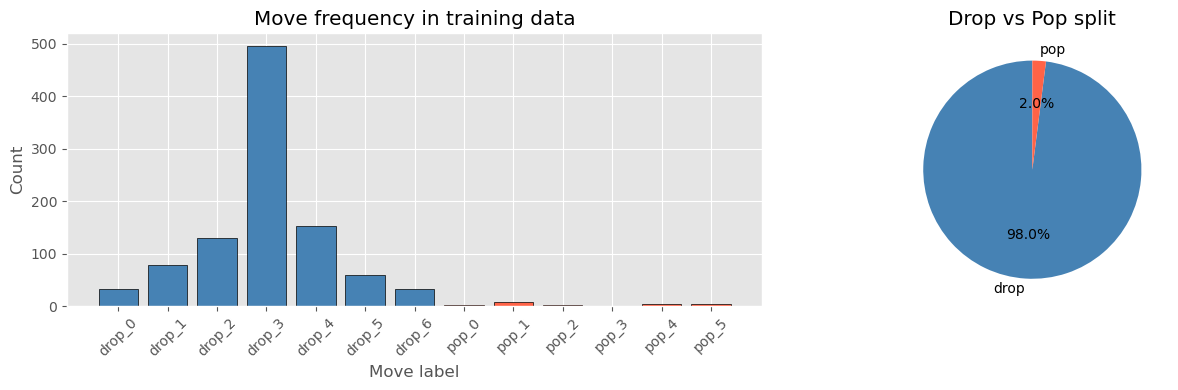

Drop moves: 980 (98.0%)   Pop moves: 20 (2.0%)


In [17]:
move_counts = df[TARGET].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Move frequency
colors = ['steelblue' if m.startswith('drop') else 'tomato' for m in move_counts.index]
axes[0].bar(move_counts.index, move_counts.values, color=colors, edgecolor='black')
axes[0].set_xlabel('Move label')
axes[0].set_ylabel('Count')
axes[0].set_title('Move frequency in training data')
axes[0].tick_params(axis='x', rotation=45)

# Drop vs pop split
n_drop = sum(1 for m in df[TARGET] if m.startswith('drop'))
n_pop  = len(df) - n_drop
axes[1].pie([n_drop, n_pop], labels=['drop', 'pop'], autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Drop vs Pop split')

plt.tight_layout()
plt.show()

print(f'Drop moves: {n_drop} ({n_drop/len(df):.1%})   Pop moves: {n_pop} ({n_pop/len(df):.1%})')

## 3. ID3 Classifier — Training

The board features from `to_feature_dict()` are already categorical:
- `cell_r_c` ∈ {0 = empty, 1 = player 1, 2 = player 2}  (42 features)
- `current_player` ∈ {1, 2}  (1 feature)

No discretisation step is needed — we pass them directly to `ID3Classifier`.

The dataset is split 80 / 20 for training and testing.  The model is the same
`ID3Classifier` from `src/decision_tree/id3/learner.py`.

In [18]:
# Convert integer features to string so ID3Classifier groupby keys are consistent
df_str = df.copy()
for col in FEATURE_COLS:
    df_str[col] = df_str[col].astype(str)

# 80 / 20 split (stratified by move label)
df_train = df_str.sample(frac=0.8, random_state=42).reset_index(drop=True)
df_test  = df_str.drop(df_train.index).reset_index(drop=True)

print(f'Train: {len(df_train)}  |  Test: {len(df_test)}')

clf_full = ID3Classifier(max_depth=15)
t0 = time.perf_counter()
clf_full.fit(df_train, target=TARGET)
train_time = time.perf_counter() - t0

train_acc = clf_full.score(df_train, target=TARGET)
test_acc  = clf_full.score(df_test,  target=TARGET)

print(f'Training time : {train_time:.2f} s')
print(f'Train accuracy: {train_acc:.3f}')
print(f'Test  accuracy: {test_acc:.3f}')

Train: 800  |  Test: 200
Training time : 3.90 s
Train accuracy: 0.990
Test  accuracy: 0.880


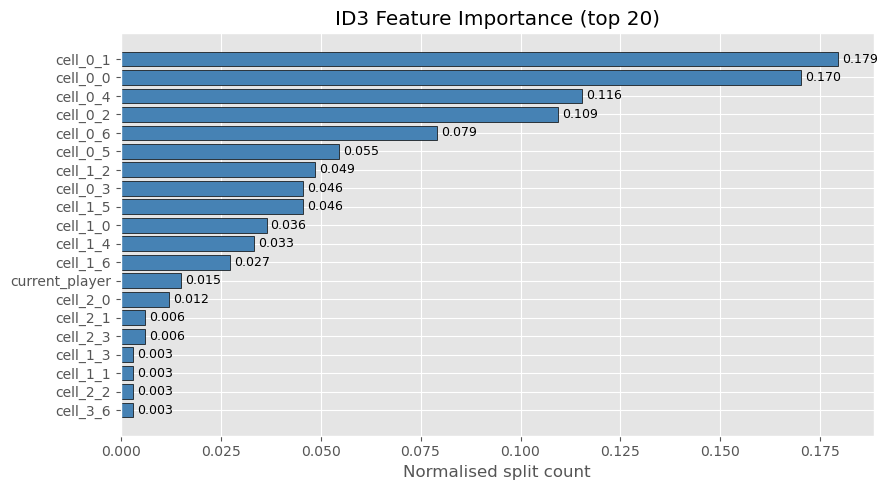

In [19]:
importance = clf_full.get_feature_importance()

# Show top 20 most-used features
top_n = 20
top_feats  = list(importance.keys())[:top_n]
top_scores = list(importance.values())[:top_n]

plt.figure(figsize=(9, 5))
bars = plt.barh(top_feats[::-1], top_scores[::-1], color='steelblue', edgecolor='black')
for bar, val in zip(bars, top_scores[::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=9)
plt.xlabel('Normalised split count')
plt.title(f'ID3 Feature Importance (top {top_n})')
plt.tight_layout()
plt.show()

## 4. Feature Sweep

We rank all features by their **information gain** on the training set, then train
separate ID3 trees using only the top-K features.  The accuracy curve reveals the
**minimum feature budget** the game requires to achieve good move prediction.

In [20]:
# Rank features by IG computed on the training set
_ranker = ID3Classifier()
ig_scores = {
    feat: _ranker.information_gain(df_train, feat, TARGET)
    for feat in FEATURE_COLS
}
ranked_features = sorted(ig_scores, key=ig_scores.get, reverse=True)

print('Top 10 features by information gain:')
for i, f in enumerate(ranked_features[:10], 1):
    print(f'  {i:2d}. {f:<18}  IG = {ig_scores[f]:.4f}')

Top 10 features by information gain:
   1. cell_1_3            IG = 0.1344
   2. cell_0_3            IG = 0.1042
   3. cell_0_5            IG = 0.0782
   4. cell_1_1            IG = 0.0689
   5. cell_2_3            IG = 0.0665
   6. cell_0_0            IG = 0.0548
   7. cell_0_1            IG = 0.0547
   8. cell_1_0            IG = 0.0536
   9. cell_0_4            IG = 0.0526
  10. cell_0_2            IG = 0.0522


In [21]:
K_VALUES = [1, 3, 5, 10, 15, 20, 30, len(FEATURE_COLS)]
sweep_results = []

for k in K_VALUES:
    top_k_feats = ranked_features[:k]
    cols = top_k_feats + [TARGET]

    clf_k = ID3Classifier(max_depth=15)
    clf_k.fit(df_train[cols], target=TARGET)

    train_a = clf_k.score(df_train[cols], target=TARGET)
    test_a  = clf_k.score(df_test[cols],  target=TARGET)
    sweep_results.append({'K': k, 'Train': train_a, 'Test': test_a})
    print(f'K={k:3d}  train={train_a:.3f}  test={test_a:.3f}')

sweep_df = pd.DataFrame(sweep_results)

K=  1  train=0.505  test=0.535
K=  3  train=0.524  test=0.530
K=  5  train=0.594  test=0.600
K= 10  train=0.949  test=0.835
K= 15  train=0.975  test=0.855
K= 20  train=0.990  test=0.875
K= 30  train=0.990  test=0.875
K= 43  train=0.990  test=0.875


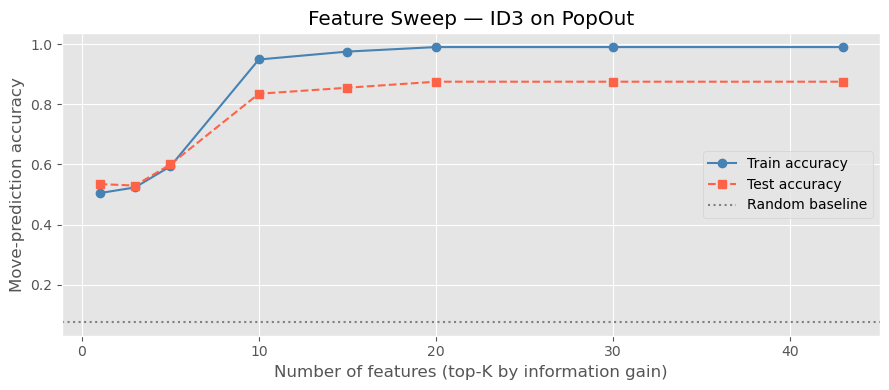

In [22]:
plt.figure(figsize=(9, 4))
plt.plot(sweep_df['K'], sweep_df['Train'], 'o-', label='Train accuracy', color='steelblue')
plt.plot(sweep_df['K'], sweep_df['Test'],  's--', label='Test accuracy',  color='tomato')
plt.axhline(1/df[TARGET].nunique(), color='gray', linestyle=':', label='Random baseline')
plt.xlabel('Number of features (top-K by information gain)')
plt.ylabel('Move-prediction accuracy')
plt.title('Feature Sweep — ID3 on PopOut')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Win-Rate Evaluation

The final ID3 tree (trained on all features) plays 100 games against
**FlatNumbaSolverMCTS** at 5 000 iterations per move.

- The tree alternates between playing as player 1 and player 2 for a balanced evaluation.
- When the tree predicts an illegal move, it falls back to a random legal move.

`warmup_solver()` is called once to pay the Numba JIT compilation cost upfront.

In [23]:
from src.mcts.optimized.numba_solver import FlatNumbaSolverMCTS, warmup_solver

print('Warming up Numba JIT (one-time cost, ~2–5 s) ...')
t0 = time.perf_counter()
warmup_solver()
print(f'Warmup done in {time.perf_counter() - t0:.1f} s')

Warming up Numba JIT (one-time cost, ~2–5 s) ...
Warmup done in 0.0 s


In [24]:
def _label_to_move(label: str) -> int:
    """Convert 'drop_c' / 'pop_c' label to move integer 0-13."""
    move_type, col = label.split('_')
    return int(col) if move_type == 'drop' else int(col) + 7


def tree_choose_move(clf: ID3Classifier, board: PopOutBoard) -> int:
    """Return the tree's chosen move, falling back to random if prediction is illegal."""
    features = board.to_feature_dict()
    row = pd.Series({k: str(v) for k, v in features.items()})
    label = clf.predict_one(row)
    move  = _label_to_move(label)
    legal = board.legal_moves()
    return move if move in legal else random.choice(legal)


def play_one_game(
    clf: ID3Classifier,
    mcts: FlatNumbaSolverMCTS,
    tree_plays_as: int,
    mcts_iterations: int,
    max_moves: int = 120,
) -> int:
    """
    Play one game tree vs MCTS.  Returns:
      +1 if the tree wins, -1 if it loses, 0 for a draw.
    """
    board = PopOutBoard()
    for _ in range(max_moves):
        legal = board.legal_moves()
        if not legal:
            return 0
        mover = board.current_player
        if mover == tree_plays_as:
            move = tree_choose_move(clf, board)
        else:
            move = mcts.run(board, iterations=mcts_iterations)
        board.apply_move(move)
        winner = evaluate_after_move(board, mover=mover)
        if winner != 0:
            return 1 if winner == tree_plays_as else -1
    return 0   # draw by move-limit

In [25]:
N_EVAL_GAMES     = 100
EVAL_ITERATIONS  = 5_000   # MCTS iterations per move during evaluation

mcts_eval = FlatNumbaSolverMCTS(max_nodes=EVAL_ITERATIONS + 256)
results   = []

t0 = time.perf_counter()
for i in range(N_EVAL_GAMES):
    tree_side = 1 if i % 2 == 0 else 2
    r = play_one_game(clf_full, mcts_eval, tree_side, EVAL_ITERATIONS)
    results.append(r)
    if (i + 1) % 10 == 0:
        w = results.count(1); l = results.count(-1); d = results.count(0)
        print(f'  [{i+1:3d}/{N_EVAL_GAMES}]  W={w}  L={l}  D={d}')

elapsed = time.perf_counter() - t0
wins   = results.count(1)
losses = results.count(-1)
draws  = results.count(0)

print(f'\nFinished {N_EVAL_GAMES} games in {elapsed:.1f} s')
print(f'Win rate : {wins/N_EVAL_GAMES:.1%}   ({wins}W / {losses}L / {draws}D)')

  [ 10/100]  W=0  L=10  D=0
  [ 20/100]  W=0  L=20  D=0
  [ 30/100]  W=0  L=30  D=0
  [ 40/100]  W=0  L=40  D=0
  [ 50/100]  W=0  L=50  D=0
  [ 60/100]  W=0  L=60  D=0
  [ 70/100]  W=0  L=70  D=0
  [ 80/100]  W=0  L=80  D=0
  [ 90/100]  W=0  L=90  D=0
  [100/100]  W=0  L=100  D=0

Finished 100 games in 10.7 s
Win rate : 0.0%   (0W / 100L / 0D)


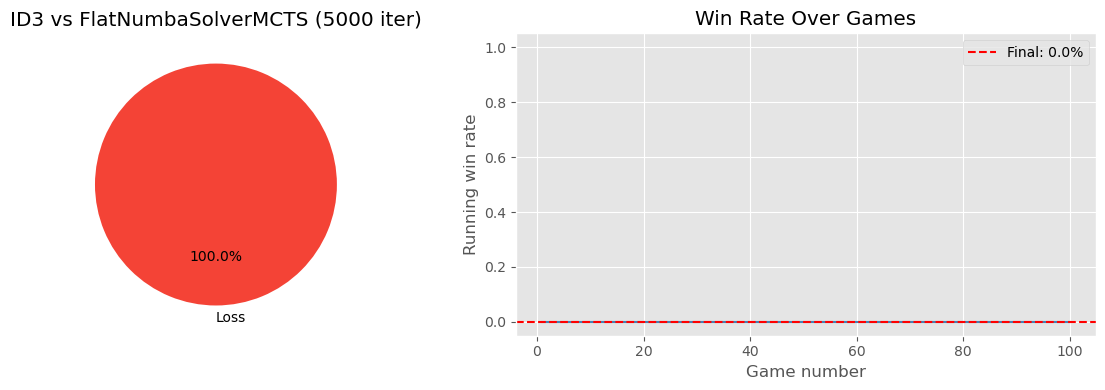


── Summary ──────────────────────────────────────────
  Dataset samples     : 1000
  Oracle iterations   : 100000
  Features used       : 43
  Test accuracy       : 0.880
  Win rate vs solver  : 0.0%
─────────────────────────────────────────────────────


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
labels = ['Win', 'Loss', 'Draw']
sizes  = [wins, losses, draws]
colors = ['#4CAF50', '#F44336', '#9E9E9E']
non_zero = [(l, s, c) for l, s, c in zip(labels, sizes, colors) if s > 0]
axes[0].pie(
    [x[1] for x in non_zero],
    labels=[x[0] for x in non_zero],
    colors=[x[2] for x in non_zero],
    autopct='%1.1f%%',
    startangle=90,
)
axes[0].set_title(f'ID3 vs FlatNumbaSolverMCTS ({EVAL_ITERATIONS} iter)')

# Running win rate
running_wr = [
    sum(1 for r in results[:i+1] if r == 1) / (i + 1)
    for i in range(len(results))
]
axes[1].plot(range(1, N_EVAL_GAMES + 1), running_wr, color='steelblue')
axes[1].axhline(wins / N_EVAL_GAMES, color='red', linestyle='--',
                label=f'Final: {wins/N_EVAL_GAMES:.1%}')
axes[1].set_xlabel('Game number')
axes[1].set_ylabel('Running win rate')
axes[1].set_title('Win Rate Over Games')
axes[1].legend()
axes[1].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

print('\n── Summary ──────────────────────────────────────────')
print(f'  Dataset samples     : {len(df)}')
print(f'  Oracle iterations   : {ITERATIONS}')
print(f'  Features used       : {len(FEATURE_COLS)}')
print(f'  Test accuracy       : {test_acc:.3f}')
print(f'  Win rate vs solver  : {wins/N_EVAL_GAMES:.1%}')
print('─────────────────────────────────────────────────────')